In [5]:
from pathlib import Path
import platform
import re
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from scipy import stats
import openpyxl

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print(f"Python: {platform.python_version()}")


Python: 3.14.6


In [11]:
SRC_DIR = next(candidate / "src" for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "data" / "raw").is_dir())
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from data.project_paths import find_project_root
from data.data_cleaning import prepare_dryer_map
PROJECT_ROOT = find_project_root()
FIGURES_DIR = PROJECT_ROOT  / "figures" 
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "dryerMAP_prototype.xlsx"
dryerMAP = prepare_dryer_map(pd.read_excel(DATA_PATH))
print(f"Loaded {DATA_PATH}")
print(dryerMAP.columns.tolist())
dryerMAP.head(10)

Loaded c:\Users\pc\Documents\GitHub\PROJECTS\MAP-Dryer-AI\data\raw\dryerMAP_prototype.xlsx
['date', 'time', 'dryer_air_temperature', 'cooler_air_temperature', 'air_flow_rate', 'wet_product_feed_rate', 'product_inlet_temperature', 'residence_time', 'vacuum', 'steam_pressure', 'fan_speed', 'product_density', 'final_product_temp', 'final_moisture_h₂o', 'timestamp']


c:\Users\pc\Documents\GitHub\PROJECTS\MAP-Dryer-AI\src\data\data_cleaning.py:72: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(


,date,time,dryer_air_temperature,cooler_air_temperature,air_flow_rate,wet_product_feed_rate,product_inlet_temperature,residence_time,vacuum,steam_pressure,fan_speed,product_density,final_product_temp,final_moisture_h₂o,timestamp
0,2026-05-01,01:00:00,140.8,18.0,19.95,9.73,61.1,23.08,-0.98,4.2,78.9,1.021,45.6,0.081,2026-01-05 01:00:00
1,2026-05-01,03:00:00,139.6,22.8,19.94,9.82,61.2,21.95,-1.0,4.27,79.7,1.027,43.8,0.115,2026-01-05 03:00:00
2,2026-05-01,05:00:00,140.4,23.6,20.98,9.62,63.2,21.79,-1.01,4.13,82.1,1.026,43.1,0.084,2026-01-05 05:00:00
3,2026-05-01,07:00:00,138.7,24.7,20.05,10.31,64.3,20.94,-1.13,4.13,83.1,1.024,44.5,0.105,2026-01-05 07:00:00
4,2026-05-01,09:00:00,141.0,26.7,19.72,10.11,63.0,21.89,-0.98,4.66,82.8,1.03,46.5,0.083,2026-01-05 09:00:00
5,2026-05-01,11:00:00,141.0,28.1,20.68,9.56,61.1,21.84,-0.98,4.07,80.2,1.02,47.6,0.097,2026-01-05 11:00:00
6,2026-05-01,13:00:00,140.8,29.8,21.01,9.48,64.5,21.31,-1.26,4.31,78.9,1.017,45.9,0.069,2026-01-05 13:00:00
7,2026-05-01,15:00:00,142.8,27.7,20.35,10.4,63.0,21.8,-1.19,4.48,81.2,1.038,47.4,0.076,2026-01-05 15:00:00
8,2026-05-01,17:00:00,140.5,27.1,20.11,10.2,61.8,21.84,-1.03,4.17,77.9,1.031,46.6,0.082,2026-01-05 17:00:00
9,2026-05-01,19:00:00,139.7,26.1,20.4,9.8,61.4,22.53,-1.01,4.12,77.2,1.029,45.2,0.117,2026-01-05 19:00:00


In [18]:
expected_columns = ['date', 'time', 'dryer_air_temperature', 'cooler_air_temperature', 'air_flow_rate', 'wet_product_feed_rate', 'product_inlet_temperature', 'residence_time', 'vacuum', 'steam_pressure', 'fan_speed', 'product_density', 'final_product_temp', 'final_moisture_h₂o']
assert dryerMAP.columns[:len(expected_columns)].tolist() == expected_columns, "Unexpected dataset schema."

duplicate_count = int(dryerMAP.duplicated().sum())
dryerMAP_unique = dryerMAP.drop_duplicates().reset_index(drop=True)
dryerMAP_unique.to_excel(PROCESSED_DIR / "dryerMAP_prototype_deduplicated.xlsx", index=False)
validation_summary = pd.Series({
    "rows_raw": len(dryerMAP),
    "columns": dryerMAP.shape[1],
    "missing_values": int(dryerMAP[expected_columns].isna().sum().sum()),
    "exact_duplicate_rows": duplicate_count,
    "duplicate_percentage": 100 * duplicate_count / len(dryerMAP),
    "rows_after_deduplication": len(dryerMAP_unique),
    
})
validation_summary.round(2)

rows_raw                    1092.00
columns                       15.00
missing_values                31.00
exact_duplicate_rows          10.00
duplicate_percentage           0.92
rows_after_deduplication    1082.00
dtype: float64

In [19]:
dryerMAP_unique["final_moisture_h₂o"] = pd.to_numeric(
    dryerMAP_unique["final_moisture_h₂o"], errors="coerce"
)

In [16]:
from stats.descriptive_statistics import descriptive_summary
descriptive_summary(dryerMAP_unique).round(4)


,count,mean,std,variance,min,25%,50%,75%,max,skewness,excess_kurtosis
dryer_air_temperature,1081.0,140.022,1.6537,2.7347,134.3,138.9,140.0,141.1,145.4,0.0406,-0.0047
cooler_air_temperature,1078.0,25.0785,3.6084,13.0209,18.0,22.0,25.1,28.1,33.8,0.0088,-1.04
air_flow_rate,1081.0,20.3775,0.9327,0.8699,17.01,19.73,20.35,20.99,23.31,0.1415,0.0185
wet_product_feed_rate,1081.0,9.9176,0.6155,0.3789,8.17,9.49,9.89,10.36,11.59,0.0899,-0.3828
product_inlet_temperature,1082.0,62.3112,2.1536,4.6382,55.5,60.9,62.2,63.8,68.5,-0.0575,0.0837
residence_time,1081.0,21.704,0.8228,0.677,19.19,21.17,21.7,22.27,24.37,-0.058,-0.1532
vacuum,1079.0,-1.1186,0.1406,0.0198,-1.54,-1.21,-1.11,-1.02,-0.68,-0.07,-0.0031
steam_pressure,1079.0,4.299,0.3178,0.101,3.3,4.09,4.3,4.51,5.48,-0.0128,-0.0531
fan_speed,1076.0,80.61,3.5503,12.6047,70.7,78.075,80.5,83.1,92.9,0.1335,-0.1346
product_density,1078.0,1.0255,0.0075,0.0001,1.003,1.02,1.025,1.03,1.05,0.0353,-0.0512


C:\Users\pc\AppData\Local\Temp\ipykernel_12924\72903147.py:5: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_12924\72903147.py:6: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / "production_feature_distributions.png", dpi=300, bbox_inches="tight")
c:\Users\pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


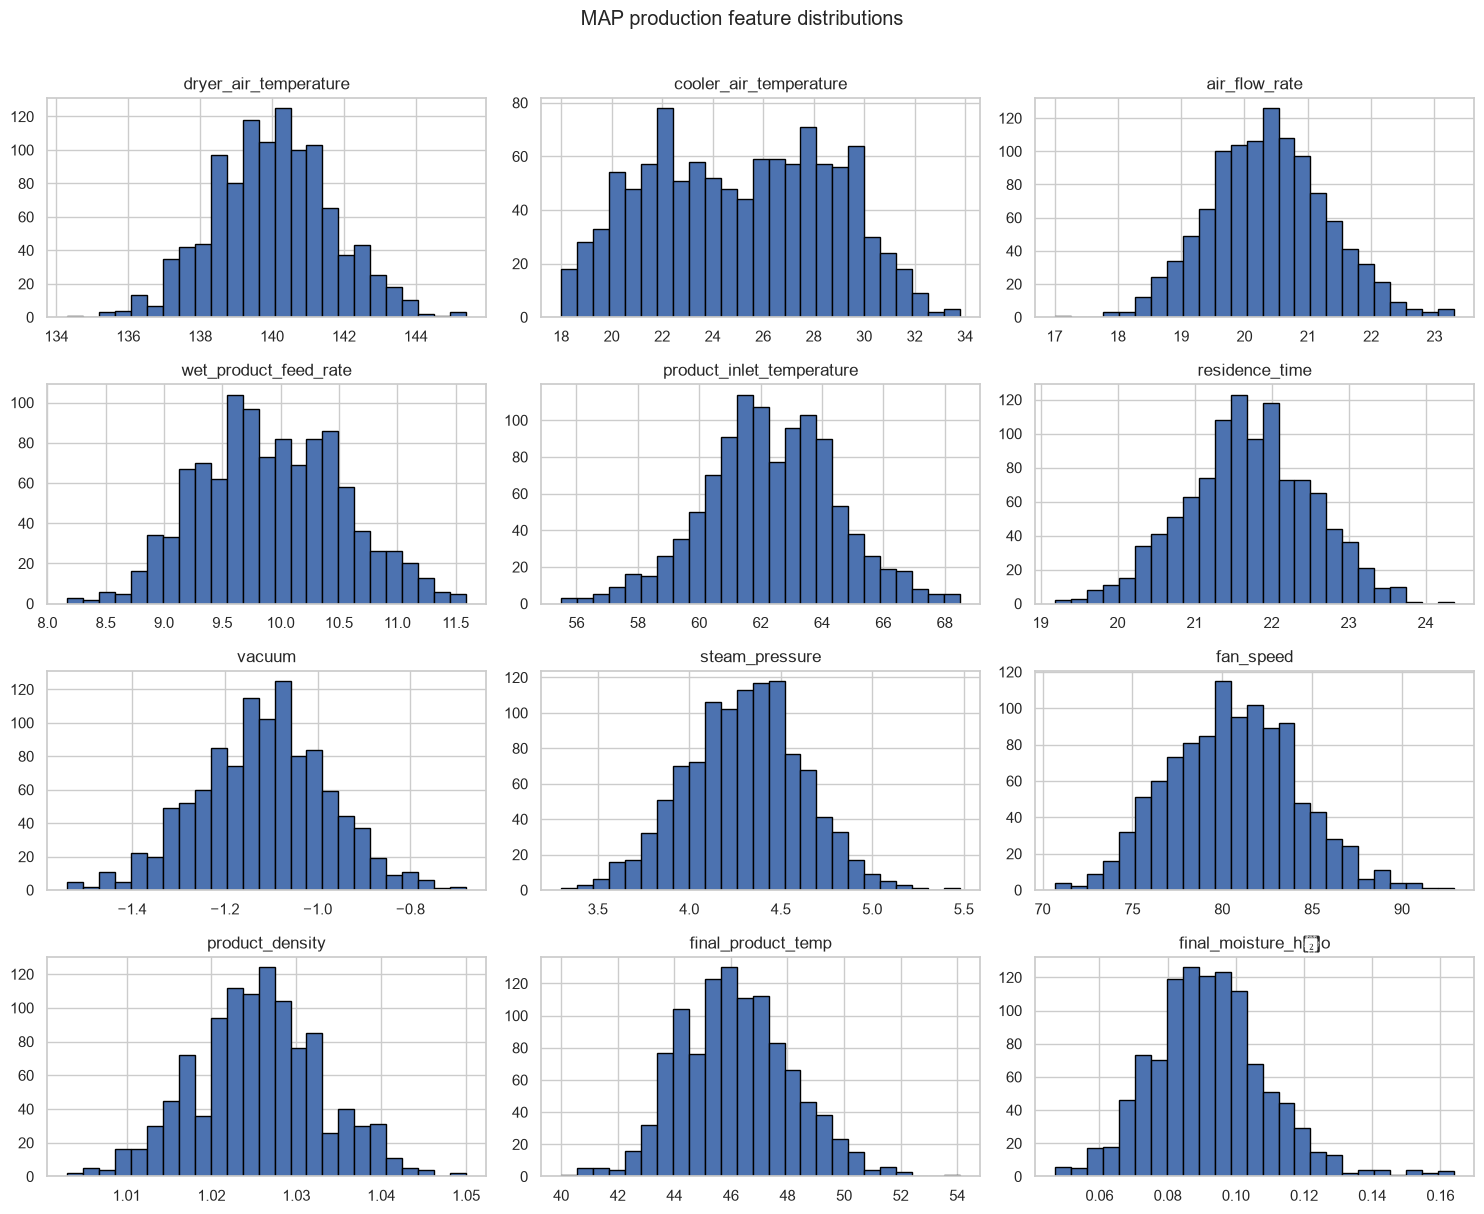

In [17]:
feature_columns =  dryerMAP_unique.select_dtypes(include="number").columns

dryerMAP_unique[feature_columns].hist(figsize=(15, 12), bins=25, edgecolor="black")
plt.suptitle("MAP production feature distributions", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "production_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()